###Compas Analysis

This step initializes the Python environment for data loading,
equivalent to the R setup using read.csv.

In [2]:
# Data loading and basic setup

import pandas as pd
import warnings

warnings.filterwarnings('ignore')

In [3]:
# Load dataset (equivalent to read.csv in R)
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)

In [4]:
# Check number of rows (equivalent to nrow in R)
print("Number of rows:", raw_data.shape[0])

Number of rows: 7214


In [5]:
# Display first 10 rows (equivalent to head in R)
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


Not all observations in the dataset are suitable for analysis due to data quality issues.

Rows are removed based on the following criteria:
- Cases where the charge date is more than 30 days from the arrest date are excluded.
- Observations with missing recidivism information (is_recid = -1) are removed.
- Minor traffic offenses (c_charge_degree = 'O') are excluded as they do not lead to jail time.
- Only individuals with valid two-year follow-up periods are retained.

### Data Cleaning and Feature Engineering

This step replicates the data preprocessing performed in the R workflow.

The following steps are applied:
- Select relevant variables
- Filter out invalid or unreliable observations
- Convert variable types
- Create derived categorical variables with reference levels

In [6]:
# Select relevant columns (equivalent to dplyr::select)
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid",
    "c_jail_in", "c_jail_out"
]].copy()

# ----------------------------
# Filtering (equivalent to dplyr::filter)
# ----------------------------

df = df[
    (df["days_b_screening_arrest"] >= -30) &
    (df["days_b_screening_arrest"] <= 30) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
]

# ----------------------------
# Type conversions
# ----------------------------

# Convert datetime variables
df["c_jail_in"] = pd.to_datetime(df["c_jail_in"])
df["c_jail_out"] = pd.to_datetime(df["c_jail_out"])

# Convert categorical variables (equivalent to factor in R)
categorical_cols = [
    "c_charge_degree", "race", "age_cat",
    "score_text", "sex"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

# ----------------------------
# Derived variables (equivalent to mutate + factor + relevel)
# ----------------------------

# crime_factor
df["crime_factor"] = df["c_charge_degree"]

# age_factor (reference: 25 - 45)
df["age_factor"] = df["age_cat"]
df["age_factor"] = pd.Categorical(
    df["age_factor"],
    categories=["25 - 45", "Less than 25", "Greater than 45"],
    ordered=False
)

# race_factor (reference: Caucasian)
df["race_factor"] = df["race"]

# gender_factor (Male as reference)
df["gender_factor"] = df["sex"].map({
    "Female": "Female",
    "Male": "Male"
})

# score_factor (Low vs High)
df["score_factor"] = df["score_text"].apply(
    lambda x: "LowScore" if x == "Low" else "HighScore"
)

# ----------------------------
# Check number of rows
# ----------------------------

print("Number of rows after filtering:", df.shape[0])

Number of rows after filtering: 6172


In [7]:
### This step replicates the `glimpse()` function in R by examining the structure and data types of the dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   age                      6172 non-null   int64         
 1   c_charge_degree          6172 non-null   category      
 2   race                     6172 non-null   category      
 3   age_cat                  6172 non-null   category      
 4   score_text               6172 non-null   category      
 5   sex                      6172 non-null   category      
 6   priors_count             6172 non-null   int64         
 7   days_b_screening_arrest  6172 non-null   float64       
 8   decile_score             6172 non-null   int64         
 9   is_recid                 6172 non-null   int64         
 10  two_year_recid           6172 non-null   int64         
 11  c_jail_in                6172 non-null   datetime64[ns]
 12  c_jail_out               6172 non-null 

Length of Stay and Correlation Analysis

In [8]:
#This step computes the length of stay using jail in and out dates.
#It then examines the relationship between COMPAS decile scores and length of stay using correlation analysis.

# Compute length of stay (equivalent to R date difference)
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days

# Compute correlation (equivalent to cor() in R)
correlation = df["length_of_stay"].corr(df["decile_score"])

print("Correlation:", correlation)

Correlation: 0.20747808478031807


The correlation is approximately 0.2, indicating a weak positive relationship.
This suggests that higher COMPAS scores are slightly associated with longer jail stays.

In [9]:
# Age category summary
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [10]:
# Race summary
df["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [11]:

# Race percentages
race_pct = df["race"].value_counts(normalize=True) * 100

print(f"Black defendants: {race_pct['African-American']:.2f}%")
print(f"White defendants: {race_pct['Caucasian']:.2f}%")
print(f"Hispanic defendants: {race_pct['Hispanic']:.2f}%")
print(f"Asian defendants: {race_pct['Asian']:.2f}%")
print(f"Native American defendants: {race_pct['Native American']:.2f}%")

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [12]:
# COMPAS score summary
df["score_text"].value_counts()

,count
score_text,
Low,3421
Medium,1607
High,1144


In [13]:
# Sex by race table
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [14]:
# Sex summary
df["sex"].value_counts()

,count
sex,
Male,4997
Female,1175


In [15]:
# Sex percentages
sex_pct = df["sex"].value_counts(normalize=True) * 100

print(f"Men: {sex_pct['Male']:.2f}%")
print(f"Women: {sex_pct['Female']:.2f}%")

Men: 80.96%
Women: 19.04%


In [16]:
# Number of defendants who recidivated within two years
(df["two_year_recid"] == 1).sum()

np.int64(2809)

In [17]:
# Percentage of defendants who recidivated within two years
(df["two_year_recid"] == 1).mean() * 100

np.float64(45.51198963058976)

** Brief summary:**  
After filtering, the sample is primarily composed of defendants aged 25–45, with African-American defendants representing the largest racial group. Most defendants are male, and the largest COMPAS score category is Low. About 45.5% of defendants recidivated within two years.

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

### Decile Score Distribution by Race

This section compares the distribution of COMPAS decile scores for African-American and Caucasian defendants. A cross-tabulation of decile score by race is also provided to examine the score distribution across racial groups.

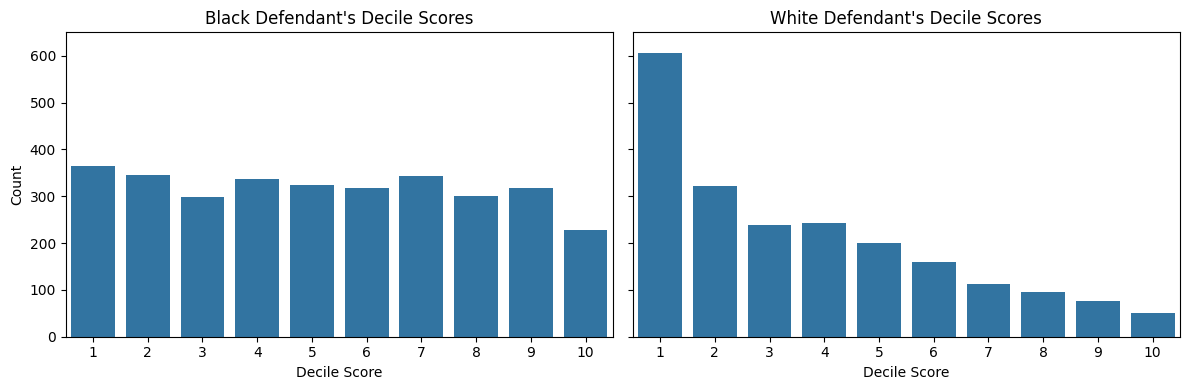

In [19]:
# Create side-by-side bar charts for decile score distributions by race
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# African-American defendants
sns.countplot(
    data=df[df["race"] == "African-American"],
    x="decile_score",
    order=sorted(df["decile_score"].dropna().unique()),
    ax=axes[0]
)
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 650)

# Caucasian defendants
sns.countplot(
    data=df[df["race"] == "Caucasian"],
    x="decile_score",
    order=sorted(df["decile_score"].dropna().unique()),
    ax=axes[1]
)
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [20]:
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


**Interpretation:**  
The decile score distributions are not the same across racial groups. African-American defendants appear more represented in higher decile score categories, while Caucasian defendants appear more concentrated in lower decile score categories.

## Racial Bias in COMPAS

After filtering out invalid or unreliable observations, we investigate whether COMPAS scores differ systematically across racial groups.

To do this, we convert relevant variables into categorical factors and estimate a logistic regression model. The dependent variable compares high risk scores to low risk scores, allowing us to examine how race and other factors are associated with the likelihood of receiving a higher COMPAS score.

The model controls for:
- Gender
- Age category
- Race
- Prior offenses (priors_count)
- Charge degree
- Two-year recidivism

This allows us to isolate the relationship between race and COMPAS scores while holding other variables constant.

In [21]:
import statsmodels.formula.api as smf

# Create binary outcome variable
df["score_binary"] = (df["score_text"] != "Low").astype(int)

# Logistic regression model
model = smf.logit(
    formula="""
    score_binary ~ C(gender_factor) + C(age_factor) + C(race_factor)
    + priors_count + C(crime_factor) + two_year_recid
    """,
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_binary   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        15:13:02   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                            -0.8271      0.091     -9

In [22]:
import numpy as np

# baseline probability (intercept)
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

# race effect (coefficient = 0.47721)
result = np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))

print(result)

1.4528408658138932


In [27]:
# baseline probability（control）

coef = 0.22127   #  gender coefficient
result = np.exp(coef) / (1 - control + control * np.exp(coef))
print(result)

1.1947978508506671


In [28]:
coef = 1.30839 # age coefficient

result = np.exp(coef) / (1 - control + (control * np.exp(coef)))

print(result)

2.4961202077189455


In [29]:
# Generate predicted probabilities, convert them into binary classifications using a 0.5 threshold,
# and map numeric predictions (0/1) to human-readable labels ("No Recid", "Recid")
df["pred_prob"] = model.predict(df)
df["pred_class"] = (df["pred_prob"] >= 0.5).astype(int)
df["pred_label"] = df["pred_class"].map({0: "No Recid", 1: "Recid"})

In [30]:
# Compute the confusion matrix, extract TP/TN/FP/FN, and calculate evaluation metrics
# including accuracy, precision, recall, false positive rate (FPR), and false negative rate (FNR)
overall_cm = pd.crosstab(
    df["pred_label"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print("\n— Overall Confusion Matrix —\n")
print(overall_cm)

TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]

n = overall_cm.values.sum()

accuracy = (TP + TN) / n
precision = TP / (TP + FP)
recall = TP / (TP + FN)
fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


— Overall Confusion Matrix —

Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [31]:
# Compute confusion matrix metrics for each racial group,
# including TP, TN, FP, FN, and performance metrics such as
# accuracy, precision, recall, FPR, and FNR

print("\n\n— Confusion Matrix by Race —\n")

race_metrics = []

for race, group in df.groupby("race"):

    actual = group["two_year_recid"].astype(int)
    pred = group["pred_class"].astype(int)

    TP = ((pred == 1) & (actual == 1)).sum()
    TN = ((pred == 0) & (actual == 0)).sum()
    FP = ((pred == 1) & (actual == 0)).sum()
    FN = ((pred == 0) & (actual == 1)).sum()

    n = len(group)

    race_metrics.append({
        "race": race,
        "n": n,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Accuracy": round((TP + TN) / n, 3),
        "Precision": round(TP / (TP + FP), 3) if (TP + FP) > 0 else None,
        "Recall": round(TP / (TP + FN), 3) if (TP + FN) > 0 else None,
        "FPR": round(FP / (FP + TN), 3) if (FP + TN) > 0 else None,
        "FNR": round(FN / (FN + TP), 3) if (FN + TP) > 0 else None
    })

race_metrics_df = pd.DataFrame(race_metrics).sort_values(by="n", ascending=False)

print(race_metrics_df)



— Confusion Matrix by Race —

               race     n    TP    TN   FP   FN  Accuracy  Precision  Recall  \
0  African-American  3175  1373   959  555  288     0.734      0.712   0.827   
2         Caucasian  2103   381  1148  133  441     0.727      0.741   0.464   
3          Hispanic   509    81   306   14  108     0.760      0.853   0.429   
5             Other   343    22   216    3  102     0.694      0.880   0.177   
1             Asian    31     2    22    1    6     0.774      0.667   0.250   
4   Native American    11     5     2    4    0     0.636      0.556   1.000   

     FPR    FNR  
0  0.367  0.173  
2  0.104  0.536  
3  0.044  0.571  
5  0.014  0.823  
1  0.043  0.750  
4  0.667  0.000  


In [32]:
# Compute FPR and FNR disparities across racial groups using Caucasian as the baseline

print("\n\n— FPR and FNR Disparity by Race —\n")


baseline = race_metrics_df[race_metrics_df["race"] == "Caucasian"].iloc[0]

baseline_fpr = baseline["FPR"]
baseline_fnr = baseline["FNR"]

disparity = race_metrics_df[["race", "n", "FPR", "FNR"]].copy()

disparity["delta_FPR"] = (disparity["FPR"] - baseline_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - baseline_fnr).round(3)

print(disparity)



— FPR and FNR Disparity by Race —

               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.367  0.173      0.263     -0.363
2         Caucasian  2103  0.104  0.536      0.000      0.000
3          Hispanic   509  0.044  0.571     -0.060      0.035
5             Other   343  0.014  0.823     -0.090      0.287
1             Asian    31  0.043  0.750     -0.061      0.214
4   Native American    11  0.667  0.000      0.563     -0.536
